In [4]:
import pandas as pd

# =========================
# LOAD DATA
# =========================
train_path = "gold_train_data.csv"
test_path = "gold_test_data.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# =========================
# ADD num_pings COLUMN
# =========================
train_df["num_pings"] = train_df.groupby("voyage_id")["voyage_id"].transform("size")
test_df["num_pings"] = test_df.groupby("voyage_id")["voyage_id"].transform("size")

# =========================
# OPTIONAL: SAVE UPDATED FILES
# =========================
train_df.to_csv("gold_train_data_with_num_pings.csv", index=False)
test_df.to_csv("gold_test_data_with_num_pings.csv", index=False)

# =========================
# CHECK RESULTS
# =========================
print("TRAIN PREVIEW:")
print(train_df[["voyage_id", "num_pings"]].head(15))

print("\nTEST PREVIEW:")
print(test_df[["voyage_id", "num_pings"]].head(15))

TRAIN PREVIEW:
       voyage_id  num_pings
0   20_205089000          5
1   20_205089000          5
2   20_205089000          5
3   20_205089000          5
4   20_205089000          5
5    5_205670000          7
6    5_205670000          7
7    5_205670000          7
8    5_205670000          7
9    5_205670000          7
10   5_205670000          7
11   5_205670000          7
12   2_205681000         62
13   2_205681000         62
14   2_205681000         62

TEST PREVIEW:
       voyage_id  num_pings
0    4_205460000         11
1    4_205460000         11
2    4_205460000         11
3    4_205460000         11
4    4_205460000         11
5    4_205460000         11
6    4_205460000         11
7    4_205460000         11
8    4_205460000         11
9    4_205460000         11
10   4_205460000         11
11  61_209729000          5
12  61_209729000          5
13  61_209729000          5
14  61_209729000          5


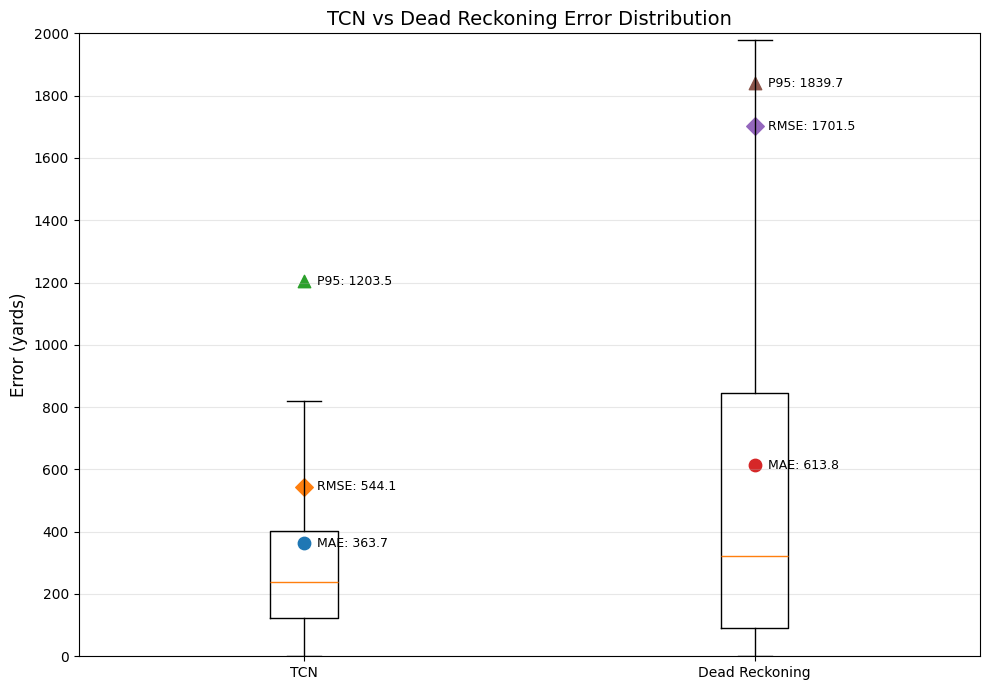

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# PRECOMPUTED SUMMARY STATS
# ==========================================
tcn_stats = {
    "label": "TCN",
    "q1": 123.47,
    "median": 237.95,
    "q3": 401.29,
    "whislo": -293.18,
    "whishi": 818.03,
    "mean": 363.67,   # MAE
    "rmse": 544.14,
    "p95": 1203.47,
}

dr_stats = {
    "label": "Dead Reckoning",
    "q1": 89.69,
    "median": 320.85,
    "q3": 845.49,
    "whislo": -1044.01,
    "whishi": 1979.19,
    "mean": 613.80,   # MAE
    "rmse": 1701.45,
    "p95": 1839.71,
}

# ==========================================
# BUILD BOXPLOT INPUT
# ==========================================
bxp_stats = [
    {
        "label": tcn_stats["label"],
        "q1": tcn_stats["q1"],
        "med": tcn_stats["median"],
        "q3": tcn_stats["q3"],
        "whislo": max(0, tcn_stats["whislo"]),
        "whishi": tcn_stats["whishi"],
        "fliers": []
    },
    {
        "label": dr_stats["label"],
        "q1": dr_stats["q1"],
        "med": dr_stats["median"],
        "q3": dr_stats["q3"],
        "whislo": max(0, dr_stats["whislo"]),
        "whishi": dr_stats["whishi"],
        "fliers": []
    }
]

# ==========================================
# PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

ax.bxp(bxp_stats, showfliers=False)

x_positions = [1, 2]
stats_list = [tcn_stats, dr_stats]

for x, stats in zip(x_positions, stats_list):
    ax.scatter(x, stats["mean"], marker="o", s=80)
    ax.text(x + 0.03, stats["mean"], f"MAE: {stats['mean']:.1f}", va="center", fontsize=9)

    ax.scatter(x, stats["rmse"], marker="D", s=80)
    ax.text(x + 0.03, stats["rmse"], f"RMSE: {stats['rmse']:.1f}", va="center", fontsize=9)

    ax.scatter(x, stats["p95"], marker="^", s=80)
    ax.text(x + 0.03, stats["p95"], f"P95: {stats['p95']:.1f}", va="center", fontsize=9)

# ==========================================
# FORMATTING
# ==========================================
ax.set_title("TCN vs Dead Reckoning Error Distribution", fontsize=14)
ax.set_ylabel("Error (yards)", fontsize=12)
ax.set_ylim(0, 2000)
ax.set_yticks(range(0, 2001, 200))
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()